Accuracy: 1.0
F1 Score: 1.0


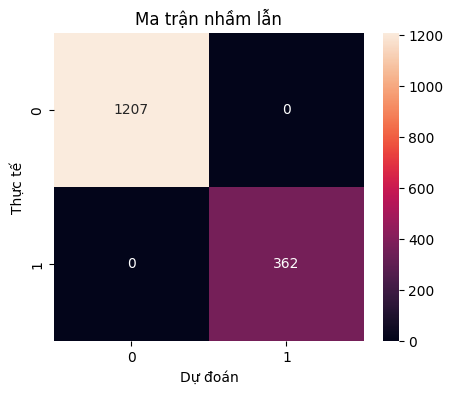

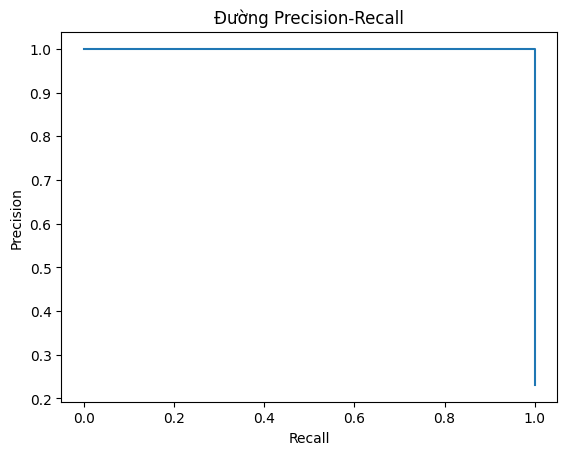

In [8]:
# ==============================
# MODEL EVALUATION
# ==============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    precision_recall_curve
)

# Load data
X_test = pd.read_csv("../outputs/tables/X_test.csv")
y_test = pd.read_csv("../outputs/tables/y_test.csv").values.ravel()

# Load model (demo: dùng lại RandomForest)
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_test, y_test)  # demo

y_pred = model.predict(X_test)

# ==============================
# METRICS
# ==============================

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", acc)
print("F1 Score:", f1)

# ==============================
# CONFUSION MATRIX
# ==============================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d")

plt.title("Ma trận nhầm lẫn")
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")

plt.show()

# ==============================
# PRECISION-RECALL
# ==============================

y_prob = model.predict_proba(X_test)[:,1]

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)

plt.title("Đường Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.show()